# B0 -> D- K+, first pass

Reading the 2024 anaprod DK tuples, settling the bachelor selection, and fitting the
B mass spectrum. The five fits in the second half are the same model under different
bachelor selections, kept in the order they were tried so the effect of each change on
the misID component stays visible.


In [ ]:
import os
import time
import math
import numpy as np
import uproot
import matplotlib.pyplot as plt
import ROOT
from ROOT import RooFit as RF
from IPython.display import Image as IPyImage, display as ipydisplay

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()

base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs loaded:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

TREE_PATH = "Tuple/DecayTree"

FILES = [
    # bd2dk_2024data_magdown_24c2a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325896/0000/00325896_00000001_1.data.root",

    # bd2dk_2024data_magup_24c2a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325899/0000/00325899_00000001_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325899/0000/00325899_00000002_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325899/0000/00325899_00000003_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325899/0000/00325899_00000004_1.data.root",

    # bd2dk_2024data_magup_24c3a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325902/0000/00325902_00000001_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325902/0000/00325902_00000002_1.data.root",

    # bd2dk_2024data_magdown_24c3a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325900/0000/00325900_00000001_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325900/0000/00325900_00000002_1.data.root",

    # bd2dk_2024data_magdown_24c4a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325905/0000/00325905_00000001_1.data.root",
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325905/0000/00325905_00000002_1.data.root",

    # bd2dk_2024data_magup_24c4a
    "/eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325906/0000/00325906_00000001_1.data.root",
]
assert all(os.path.exists(f) for f in FILES), "One or more FILES do not exist."


## Data

Twelve files across 24c2, 24c3 and 24c4, both polarities. The branch list is identical
in all of them, so it is printed once from the first file.


In [2]:
root_files = FILES

printed_branches = False  # only print full branch list once

for path in root_files:
    print(f"\nLoading file: {path}")
    try:
        with uproot.open(path) as f:
            tree = f[TREE_PATH]

            print(f"  Opened tree: {TREE_PATH}")
            print(f"  Number of entries: {tree.num_entries}")

            # the branch list is the same in every file, so print it once
            if not printed_branches:
                print(f"\n  Branches in '{TREE_PATH}':")
                for branch in tree.keys():
                    print(f"    {branch}")
                printed_branches = True

    except FileNotFoundError as e:
        print(f"  File not found: {e}")
    except KeyError as e:
        print(f"  Tree '{TREE_PATH}' not found in this file: {e}")
    except Exception as e:
        print(f"  Error reading file: {e}")



Loading file: /eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision24/DATA.ROOT/00325896/0000/00325896_00000001_1.data.root
  Opened tree: Tuple/DecayTree
  Number of entries: 17004618

  Branches in 'Tuple/DecayTree':
    totCandidates
    nCandidate
    EVENTNUMBER
    Hlt1TrackMVADecision
    Hlt1TwoTrackMVADecision
    Hlt1_TCK
    Hlt2B2OC_BdToDmK_DmToPimPimKpDecision
    Hlt2Topo2BodyDecision
    Hlt2Topo3BodyDecision
    Hlt2_TCK
    RUNNUMBER
    nFTClusters
    nLongTracks
    nPVs
    nVPClusters
    nVeloTracks
    lab0_ID
    lab0_PT
    lab0_ETA
    lab0_P
    lab0_SUMPT
    lab0_MASS
    lab0_BPVDIRA
    lab0_CHI2DOF
    lab0_BPVIPCHI2
    lab0_BPVIP
    lab0_BPVFDCHI2
    lab0_BPVLTIME
    lab0_BPVFD
    lab0_CHILD1_IPwrtSV
    lab0_CHILD1_IPCHI2wrtSV
    lab0_CHILD1_FDwrtSV
    lab0_CHILD1_FDCHI2wrtSV
    lab0_DTF_MassFitConsD_MASS
    lab0_DTF_MassFitConsD_CHI2DOF
    lab0_DTF_MassFitConsD_P
    lab0_DTF_LifetimeFit_MASS
    lab0_DTF_LifetimeFit_CHI2DOF
    lab0_DTF_Li

In [3]:
mass_branch = "lab0_MASS"   # B candidate mass

files_with_tree = {path: TREE_PATH for path in root_files}

mass_chunks = []

for arrays in uproot.iterate(
    files_with_tree,      # dict: {filename: "Tuple/DecayTree"}
    [mass_branch],        # branches to read
    library="np"
):
    mass_chunks.append(arrays[mass_branch])

masses = np.concatenate(mass_chunks)
print(f"Total events loaded: {len(masses)}")

plt.figure(figsize=(8, 6))
plt.hist(masses, bins=100, histtype="step")

plt.xlabel("lab0_MASS")
plt.ylabel("Events")
plt.title("Raw data: Events vs lab0_MASS")
plt.grid(True)

plt.show()


Total events loaded: 185086219



Total raw events (all files):     185086219
Total events after physics cuts:  107254498
Overall selection efficiency:    57.948%



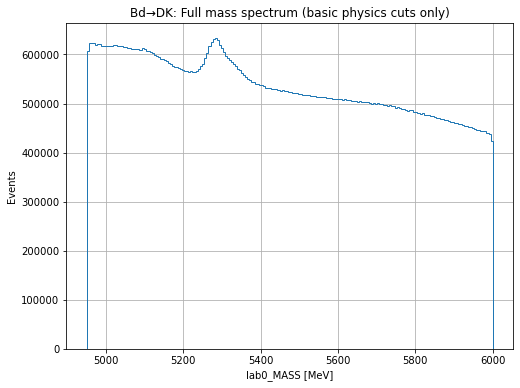

In [4]:
root_files = FILES
files_with_tree = {path: TREE_PATH for path in root_files}

branches = [
    "lab0_MASS", "lab0_BPVDIRA", "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2", "lab0_CHI2DOF",
    "lab2_MASS",  # D mass

    # Track quality + kinematics
    "lab1_PT", "lab1_TRACK_GhostProb",
    "lab3_PT", "lab3_TRACK_GhostProb",
    "lab4_PT", "lab4_TRACK_GhostProb",
    "lab5_PT", "lab5_TRACK_GhostProb",
]

d_min, d_max = 1800.0, 1940.0      # D mass window [MeV]
b_fdchi2_min  = 25.0
b_ipchi2_max  = 25.0
b_dir_min     = 0.999
b_chi2_max    = 5.0
pt_min        = 250.0              # MeV
ghost_max     = 0.4

selected_masses = []
raw_total = 0
sel_total = 0

for arrays in uproot.iterate(
    files_with_tree,
    branches,
    library="np",
    step_size="200 MB"
):
    mB      = arrays["lab0_MASS"]
    b_dir   = arrays["lab0_BPVDIRA"]
    b_fdchi2= arrays["lab0_BPVFDCHI2"]
    b_ipchi2= arrays["lab0_BPVIPCHI2"]
    b_chi2  = arrays["lab0_CHI2DOF"]
    mD      = arrays["lab2_MASS"]

    t1_pt, t1_ghost = arrays["lab1_PT"], arrays["lab1_TRACK_GhostProb"]
    t3_pt, t3_ghost = arrays["lab3_PT"], arrays["lab3_TRACK_GhostProb"]
    t4_pt, t4_ghost = arrays["lab4_PT"], arrays["lab4_TRACK_GhostProb"]
    t5_pt, t5_ghost = arrays["lab5_PT"], arrays["lab5_TRACK_GhostProb"]

    raw_total += len(mB)

    b_cuts = (
        (b_dir   > b_dir_min) &
        (b_fdchi2 > b_fdchi2_min) &
        (b_ipchi2 < b_ipchi2_max) &
        (b_chi2   < b_chi2_max)
    )
    d_cuts = (mD > d_min) & (mD < d_max)
    track_cuts = (
        (t1_pt > pt_min) & (t1_ghost < ghost_max) &
        (t3_pt > pt_min) & (t3_ghost < ghost_max) &
        (t4_pt > pt_min) & (t4_ghost < ghost_max) &
        (t5_pt > pt_min) & (t5_ghost < ghost_max)
    )

    mask = b_cuts & d_cuts & track_cuts

    sel_total += mask.sum()
    selected_masses.append(mB[mask])

masses_sel = np.concatenate(selected_masses) if selected_masses else np.array([])

print(f"Total raw events (all files):     {raw_total}")
print(f"Total events after physics cuts:  {sel_total}")
if raw_total > 0:
    print(f"Overall selection efficiency:    {sel_total / raw_total:.3%}")

plt.figure(figsize=(8, 6))
plt.hist(masses_sel, bins=200, histtype="step")  # full mass spectrum
plt.xlabel("lab0_MASS [MeV]")
plt.ylabel("Events")
plt.title("Bd→DK: Full mass spectrum (basic physics cuts only)")
plt.grid(True)
plt.show()


Total raw events:                 185086219
K-like bachelor (PIDK>8.0):   66262557
'pi-like' bachelor (PIDK<4.0): 26374904



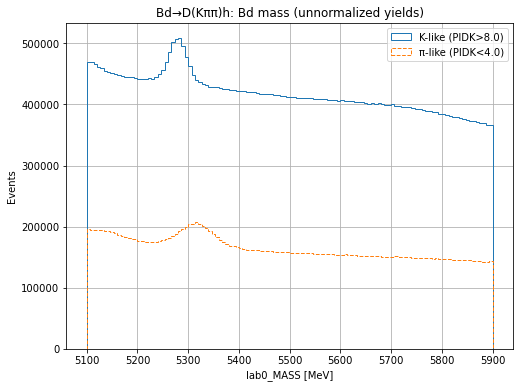

In [5]:
root_files = FILES
files_with_tree = {path: TREE_PATH for path in root_files}

branches = [
    "lab0_MASS", "lab0_BPVDIRA", "lab0_BPVFDCHI2",
    "lab0_BPVIPCHI2", "lab0_CHI2DOF",
    "lab2_MASS",
    "lab1_PT", "lab1_TRACK_GhostProb", "lab1_PIDK",
    "lab3_PT", "lab3_TRACK_GhostProb",
    "lab4_PT", "lab4_TRACK_GhostProb",
    "lab5_PT", "lab5_TRACK_GhostProb",
]

d_min, d_max = 1800.0, 1940.0
b_fdchi2_min  = 25.0
b_ipchi2_max  = 25.0
b_dir_min     = 0.999
b_chi2_max    = 5.0
pt_min        = 250.0
ghost_max     = 0.4

pidK_Klike_min  = 8.0
pidK_pilike_max = 4.0

masses_Klike  = []
masses_pilike = []

raw_total = 0
sel_Klike  = 0
sel_pilike = 0

for arrays in uproot.iterate(
    files_with_tree,
    branches,
    library="np",
    step_size="200 MB"
):
    mB      = arrays["lab0_MASS"]
    b_dir   = arrays["lab0_BPVDIRA"]
    b_fdchi2= arrays["lab0_BPVFDCHI2"]
    b_ipchi2= arrays["lab0_BPVIPCHI2"]
    b_chi2  = arrays["lab0_CHI2DOF"]
    mD      = arrays["lab2_MASS"]

    t1_pt, t1_ghost  = arrays["lab1_PT"], arrays["lab1_TRACK_GhostProb"]
    t1_PIDK          = arrays["lab1_PIDK"]

    t3_pt, t3_ghost = arrays["lab3_PT"], arrays["lab3_TRACK_GhostProb"]
    t4_pt, t4_ghost = arrays["lab4_PT"], arrays["lab4_TRACK_GhostProb"]
    t5_pt, t5_ghost = arrays["lab5_PT"], arrays["lab5_TRACK_GhostProb"]

    raw_total += len(mB)

    # physics cuts common to both regions
    b_cuts = (
        (b_dir   > b_dir_min) &
        (b_fdchi2 > b_fdchi2_min) &
        (b_ipchi2 < b_ipchi2_max) &
        (b_chi2   < b_chi2_max)
    )
    d_cuts = (mD > d_min) & (mD < d_max)
    track_common = (
        (t3_pt > pt_min) & (t3_ghost < ghost_max) &
        (t4_pt > pt_min) & (t4_ghost < ghost_max) &
        (t5_pt > pt_min) & (t5_ghost < ghost_max)
    )
    bachelor_quality = (
        (t1_pt > pt_min) &
        (t1_ghost < ghost_max)
    )

    base_mask = b_cuts & d_cuts & track_common & bachelor_quality

    # split on bachelor PID
    mask_Klike  = base_mask & (t1_PIDK > pidK_Klike_min)
    mask_pilike = base_mask & (t1_PIDK < pidK_pilike_max)

    sel_Klike  += mask_Klike.sum()
    sel_pilike += mask_pilike.sum()

    masses_Klike.append(mB[mask_Klike])
    masses_pilike.append(mB[mask_pilike])

masses_Klike  = np.concatenate(masses_Klike)  if masses_Klike  else np.array([])
masses_pilike = np.concatenate(masses_pilike) if masses_pilike else np.array([])

print(f"Total raw events:                 {raw_total}")
print(f"K-like bachelor (PIDK>{pidK_Klike_min}):   {sel_Klike}")
print(f"'pi-like' bachelor (PIDK<{pidK_pilike_max}): {sel_pilike}")

plt.figure(figsize=(8, 6))

bins = 120
mass_range = (5100, 5900)

plt.hist(masses_Klike,  bins=bins, range=mass_range,
         histtype="step", label=f"K-like (PIDK>{pidK_Klike_min})")
plt.hist(masses_pilike, bins=bins, range=mass_range,
         histtype="step", linestyle="--",
         label=f"π-like (PIDK<{pidK_pilike_max})")

plt.xlabel("lab0_MASS [MeV]")
plt.ylabel("Events")
plt.title("Bd→D(Kππ)h: Bd mass (unnormalized yields)")
plt.grid(True)
plt.legend()
plt.show()


## Signal shape from the pion-like sample

Requiring `lab1_PIDK < 4` leaves a sample dominated by B0 -> D- pi+, which fixes the peak
shape that the misidentified component of the DK fit inherits later. A Crystal Ball and
a double Gaussian are compared on the same unbinned dataset by AIC and BIC.


In [6]:
# masses_pilike comes from the PIDK < 4 split above

mass_min, mass_max = 5150., 5800.

x = ROOT.RooRealVar("x", "m(B_{d}) [MeV]", mass_min, mass_max)

data = ROOT.RooDataSet("data", "unbinned pi-like sample",
                       ROOT.RooArgSet(x))

for m in masses_pilike:
    if mass_min <= m <= mass_max:
        x.setVal(m)
        data.add(ROOT.RooArgSet(x))

print("Unbinned entries in fit range:", data.numEntries())


Unbinned entries in fit range: 16204397



In [7]:
mean_cb  = ROOT.RooRealVar("mean_cb",  "mean_cb",  5320., 5280., 5360.)
sigma_cb = ROOT.RooRealVar("sigma_cb", "sigma_cb",   20.,   5.,   60.)
alpha_cb = ROOT.RooRealVar("alpha_cb", "alpha_cb",  1.5,   0.1,   5.)
n_cb     = ROOT.RooRealVar("n_cb",     "n_cb",      3.0,   0.5,  10.)

cb = ROOT.RooCBShape("cb", "Crystal Ball signal",
                     x, mean_cb, sigma_cb, alpha_cb, n_cb)

tau_cb  = ROOT.RooRealVar("tau_cb", "tau_cb", -0.001, -1., 0.)
expo_cb = ROOT.RooExponential("expo_cb", "comb. background", x, tau_cb)

tot_yield = data.numEntries()
nsig_cb = ROOT.RooRealVar("nsig_cb", "signal yield CB",
                          0.7 * tot_yield, 0., 2.*tot_yield)
nbkg_cb = ROOT.RooRealVar("nbkg_cb", "bkg yield CB",
                          0.3 * tot_yield, 0., 2.*tot_yield)

model_cb = ROOT.RooAddPdf("model_cb", "CB+expo",
                          ROOT.RooArgList(cb, expo_cb),
                          ROOT.RooArgList(nsig_cb, nbkg_cb))

res_cb = model_cb.fitTo(
    data,
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.PrintLevel(-1)
)

NLL_cb   = res_cb.minNll()
npar_cb  = res_cb.floatParsFinal().getSize()
N_cb     = data.numEntries()
AIC_cb   = 2*npar_cb + 2*NLL_cb
BIC_cb   = npar_cb*math.log(N_cb) + 2*NLL_cb

print("\n=== Crystal Ball + exp (unbinned) ===")
for p in [mean_cb, sigma_cb, alpha_cb, n_cb, tau_cb, nsig_cb, nbkg_cb]:
    print(f"{p.GetName():8s} = {p.getVal():.4g} ± {p.getError():.4g}")
print(f"NLL  = {NLL_cb:.2f}   npar = {npar_cb}")
print(f"AIC  = {AIC_cb:.2f}")
print(f"BIC  = {BIC_cb:.2f}")



=== Crystal Ball + exp (unbinned) ===
mean_cb  = 5316 ± 0.1952
sigma_cb = 32.4 ± 0.2362
alpha_cb = 1.334 ± 0.02149
n_cb     = 0.5 ± 0.001018
tau_cb   = -0.0002842 ± 2.735e-06
nsig_cb  = 5.585e+05 ± 6499
nbkg_cb  = 1.565e+07 ± 7570
NLL  = -147923376.21   npar = 7
AIC  = -295846738.41
BIC  = -295846636.21



In [8]:
mean_dg   = ROOT.RooRealVar("mean_dg",   "mean_dg",   5320., 5280., 5360.)
sigma1_dg = ROOT.RooRealVar("sigma1_dg", "sigma1_dg", 15.,    5.,   40.)
sigma2_dg = ROOT.RooRealVar("sigma2_dg", "sigma2_dg", 30.,   10.,   80.)
frac_dg   = ROOT.RooRealVar("frac_dg",   "frac_dg",    0.7,   0.,    1.)

g1 = ROOT.RooGaussian("g1", "core gauss", x, mean_dg, sigma1_dg)
g2 = ROOT.RooGaussian("g2", "tail gauss", x, mean_dg, sigma2_dg)

sig_dg = ROOT.RooAddPdf("sig_dg", "double gauss",
                        ROOT.RooArgList(g1, g2),
                        ROOT.RooArgList(frac_dg))

# separate background parameters, so the two models stay independent
tau_dg  = ROOT.RooRealVar("tau_dg", "tau_dg", -0.001, -1., 0.)
expo_dg = ROOT.RooExponential("expo_dg", "comb. background", x, tau_dg)

nsig_dg = ROOT.RooRealVar("nsig_dg", "signal yield DG",
                          0.7 * tot_yield, 0., 2.*tot_yield)
nbkg_dg = ROOT.RooRealVar("nbkg_dg", "bkg yield DG",
                          0.3 * tot_yield, 0., 2.*tot_yield)

model_dg = ROOT.RooAddPdf("model_dg", "doubleG+expo",
                          ROOT.RooArgList(sig_dg, expo_dg),
                          ROOT.RooArgList(nsig_dg, nbkg_dg))

res_dg = model_dg.fitTo(
    data,
    ROOT.RooFit.Extended(True),
    ROOT.RooFit.Save(True),
    ROOT.RooFit.PrintLevel(-1)
)

NLL_dg   = res_dg.minNll()
npar_dg  = res_dg.floatParsFinal().getSize()
N_dg     = data.numEntries()
AIC_dg   = 2*npar_dg + 2*NLL_dg
BIC_dg   = npar_dg*math.log(N_dg) + 2*NLL_dg

print("\n=== double Gaussian + exp (unbinned) ===")
for p in [mean_dg, sigma1_dg, sigma2_dg, frac_dg, tau_dg, nsig_dg, nbkg_dg]:
    print(f"{p.GetName():8s} = {p.getVal():.4g} ± {p.getError():.4g}")
print(f"NLL  = {NLL_dg:.2f}   npar = {npar_dg}")
print(f"AIC  = {AIC_dg:.2f}")
print(f"BIC  = {BIC_dg:.2f}")



=== double Gaussian + exp (unbinned) ===
mean_dg  = 5316 ± 0.07073
sigma1_dg = 29.97 ± 0.1208
sigma2_dg = 29.89 ± 21.65
frac_dg  = 0.9681 ± 0.5797
tau_dg   = -0.0003448 ± 5.22e-07
nsig_dg  = 4e+05 ± 987.9
nbkg_dg  = 1.58e+07 ± 1557
NLL  = -147923002.32   npar = 7
AIC  = -295845990.64
BIC  = -295845888.43



In [9]:
print("\n=== Model comparison (unbinned) ===")
print(f"AIC:  CB = {AIC_cb:.2f},   doubleG = {AIC_dg:.2f}")
print(f"BIC:  CB = {BIC_cb:.2f},  doubleG = {BIC_dg:.2f}")

if AIC_cb < AIC_dg:
    print("→ AIC prefers: Crystal Ball")
else:
    print("→ AIC prefers: double Gaussian")

if BIC_cb < BIC_dg:
    print("→ BIC prefers: Crystal Ball")
else:
    print("→ BIC prefers: double Gaussian")



=== Model comparison (unbinned) ===
AIC:  CB = -295846738.41,   doubleG = -295845990.64
BIC:  CB = -295846636.21,  doubleG = -295845888.43
→ AIC prefers: Crystal Ball
→ BIC prefers: Crystal Ball



Info in <TCanvas::Print>: pdf file fit_pi_like_unbinned_CB.pdf has been created
Info in <TCanvas::Print>: pdf file fit_pi_like_unbinned_doubleG.pdf has been created



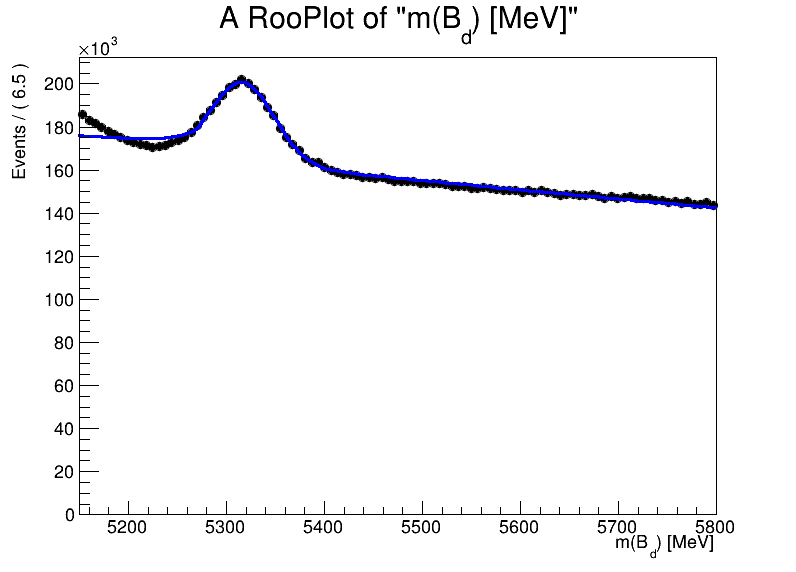

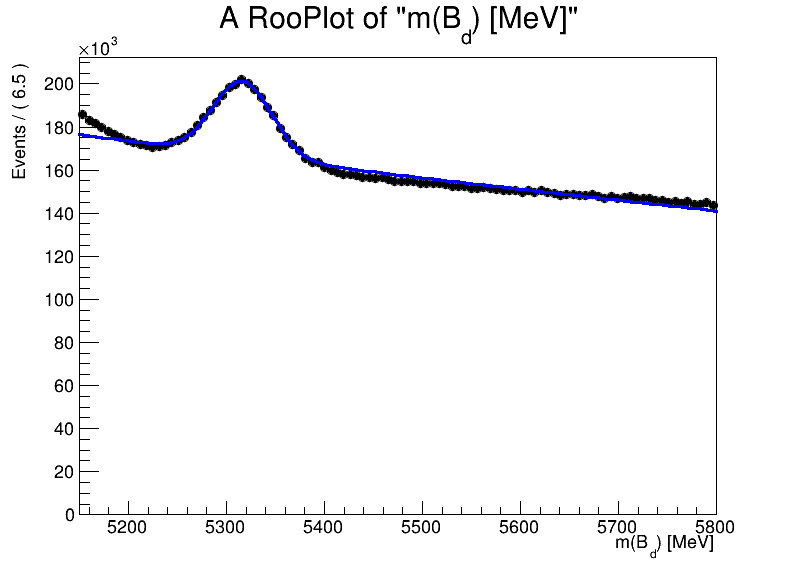

In [10]:
frame_cb = x.frame()
data.plotOn(frame_cb)
model_cb.plotOn(frame_cb)
c_cb = ROOT.TCanvas("c_cb", "CB fit (unbinned view)", 800, 600)
frame_cb.Draw()
c_cb.SaveAs("fit_pi_like_unbinned_CB.pdf")

frame_dg = x.frame()
data.plotOn(frame_dg)
model_dg.plotOn(frame_dg)
c_dg = ROOT.TCanvas("c_dg", "doubleG fit (unbinned view)", 800, 600)
frame_dg.Draw()
c_dg.SaveAs("fit_pi_like_unbinned_doubleG.pdf")


## Binned DK fit

K-like bachelor, `lab1_PIDK > 8`. Signal is a double-sided Crystal Ball; the misID
Bd -> D pi component is a Crystal Ball with its shape carried over from the pion-like fit
above. Partially reconstructed decays use HILLdini for the photon and HORNSdini for the
pi0, and the combinatorial is trained in the sidebands first so the full fit starts from
a sensible slope.


Welcome to JupyROOT 6.30/02

[build DK] applying Bd->DK cuts (K-like bachelor, vertex + D mass)...



Reading DK tuples: 72it [21:09, 17.63s/it]



[build DK] done in 1272.1s — kept 72688476 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...[#1] INFO:Eval -- RooRealVar::setRange(m) new range named 'LSB' created with bounds [4950,5150]

[prefit DK] signal+comb (DSCB, tails frozen)...

[fit DK] final binned extended likelihood, NBINS =[#1] INFO:Minimization --  Including the following constraint terms in minimization: (g_c0,g_c1,g_c2,gNg,gNpi)
BKG_comb)
imized function has error status.

)
) using numeric integrator RooRombergIntegrator to calculate Int(m)

1] INFO1:] INFONumericIntegration: -- RooRealIntegral::init(NumericIntegrationBKG_g_Int[m] -- ) using numeric integrator RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator[# to calculate Int1] RooRombergIntegratorINFO to calculate Int:NumericIntegration( -- RooRealIntegral::init([#BKG_pi_Int[m]) using numeric integrator (1RooRombergIntegrator]  to calculate IntINFO(:mNumericIntegration) -- 

BKG_pi_Int[m]) using numeric integrator Ro

Info in <TCanvas::Print>: png file /tmp/fit_DK_1762688388.png has been created



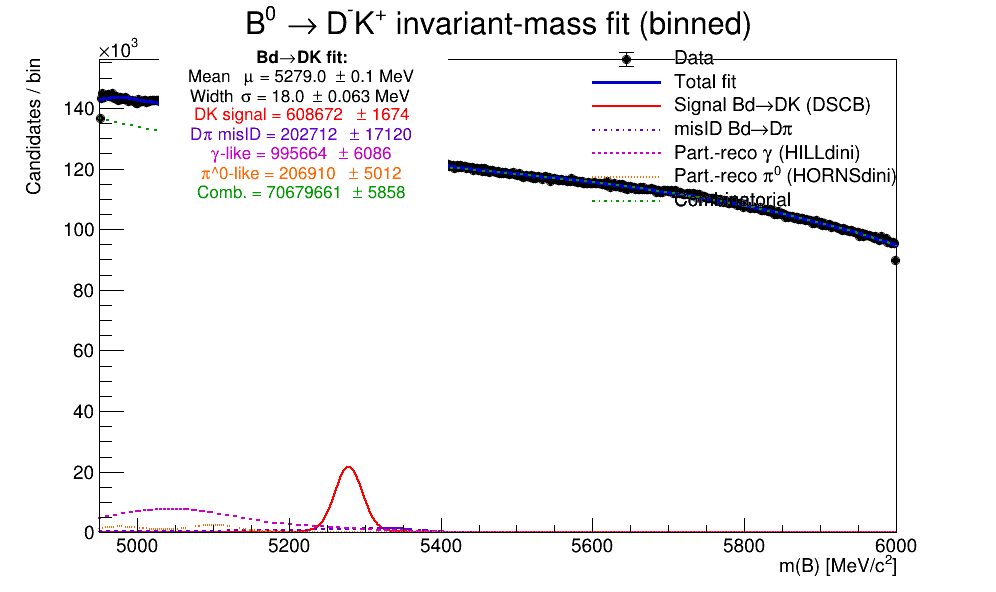

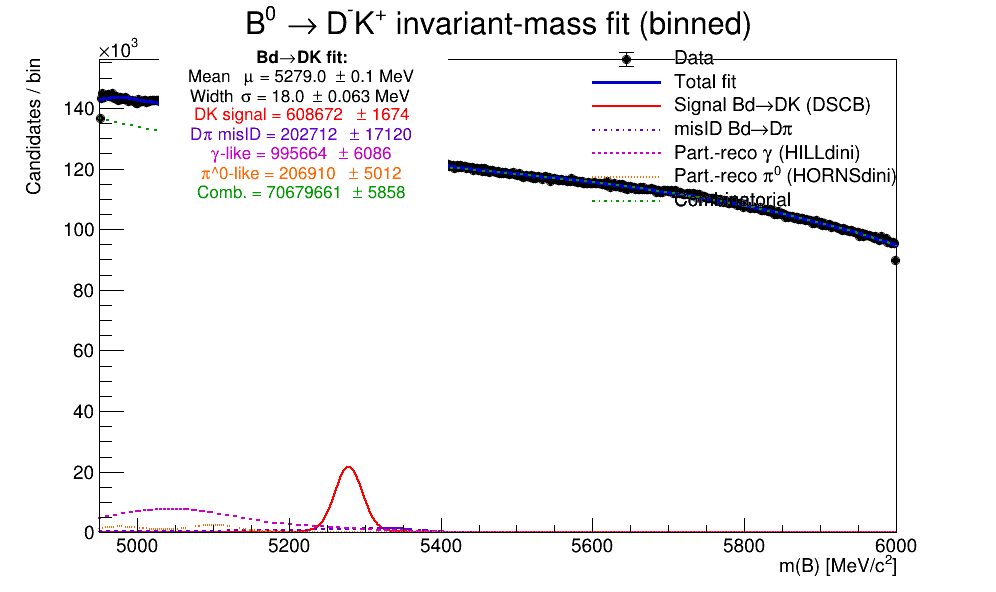

In [ ]:
DK_FILES = FILES

USE_SUBSET = False
SUBSET_N   = 500_000    # optional skim, for speed

NBINS      = 600        # fine binning, ~16 MeV core width
COMB_MODEL = "cheby"    # "cheby" or "expo"

# physics windows
D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MIN = 8.0         # kaon-like bachelor (lab1_PIDK>8)
mmin, mmax = 4950., 6000.       # full DK window

# Crystal Ball shape carried over from the unbinned PIDK < 4 fit
PI_MU0    = 5316.0     # mean_cb
PI_SIG0   = 32.4       # sigma_cb
PI_ALPHA0 = 1.334      # alpha_cb
PI_N0     = 0.5        # n_cb

# build the K-like bachelor sample
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build DK] applying Bd->DK cuts (K-like bachelor, vertex + D mass)...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in DK_FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading DK tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]
    pidk = pidk[finite]

    sel = (
        (pidk > BACHELOR_PIDK_MIN) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build DK] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No DK events after cuts/subset.")

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# sign of the combinatorial slope, seeded from a linear fit at low mass
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hDK","hDK", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhDK","binned DK", ROOT.RooArgList(m), dhist)

# seeds for the DK mean and width
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges = np.linspace(5200,5350,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model

# DK signal, a double-sided Crystal Ball
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 30.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# misidentified Bd -> Dπ, a Crystal Ball with its shape fixed by the π-like fit
pi_mu    = ROOT.RooRealVar("pi_mu",   "pi-like mean",   PI_MU0,    PI_MU0-10., PI_MU0+10.)
pi_sig   = ROOT.RooRealVar("pi_sig",  "pi-like sigma",  PI_SIG0,   PI_SIG0*0.7, PI_SIG0*1.3)
pi_alpha = ROOT.RooRealVar("pi_alpha","pi-like alpha",  PI_ALPHA0, 0.1, 5.0)
pi_n     = ROOT.RooRealVar("pi_n",    "pi-like n",      PI_N0,     0.5, 15.)

MIS = ROOT.RooCBShape("MIS","misID Dpi->DK", m, pi_mu, pi_sig, pi_alpha, pi_n)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","DK signal yield",  0.20*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","Dpi misID yield",  0.05*Ntot, 0.0, 0.50*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",      0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",        0.02*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",      0.70*Ntot, 0.0, 2.0*Ntot)

# pre-fit the combinatorial in the sidebands, and constrain it there
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

# weak priors on the partial-reco yields
mu_Ng,  sig_Ng  = 0.04*Ntot, max(1.0, 0.04*Ntot)
mu_Npi, sig_Npi = 0.02*Ntot, max(1.0, 0.02*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# prefit signal and combinatorial with the tails frozen
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_DK","pre_DK",
                         ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit DK] signal+comb (DSCB, tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf_DK","DK model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit DK] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit DK] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")


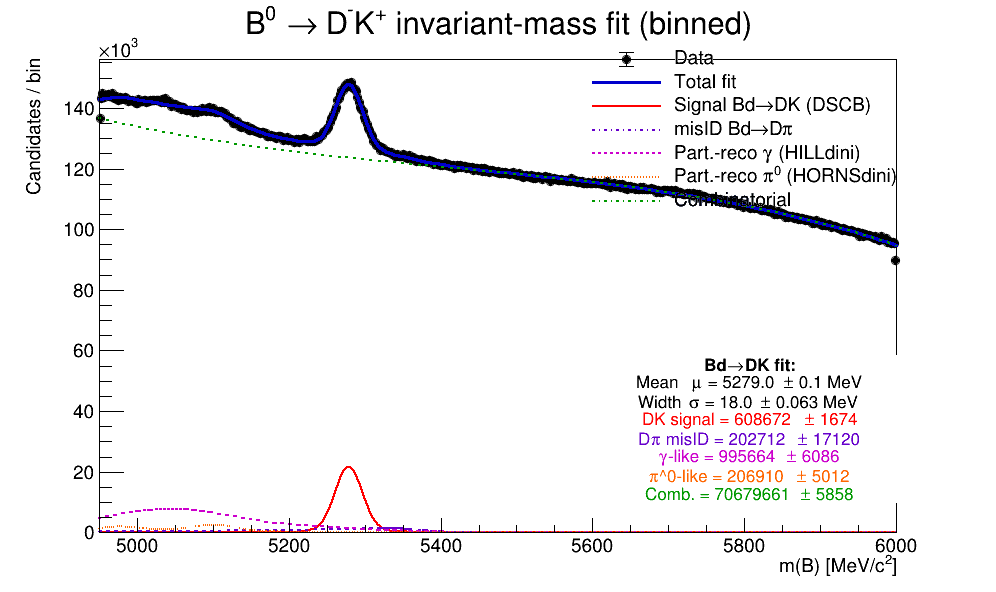



[22 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/fit_DK_1762688509.png has been created



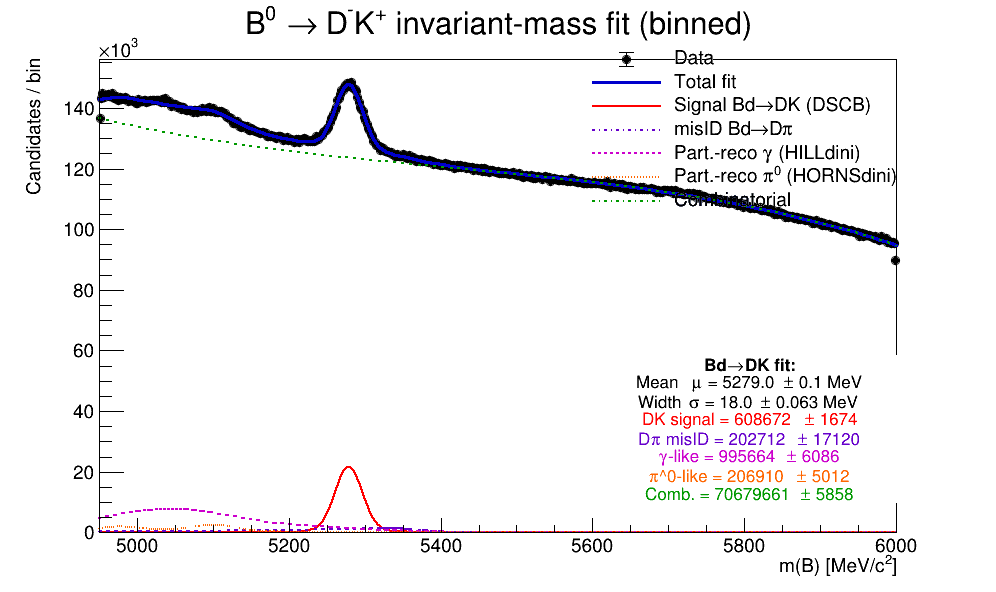

In [2]:
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_DK_{int(time.time())}","DKFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                       "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                  "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID Bd#rightarrowD#pi",       "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)",  "l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",                 "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Bd#rightarrowDK fit:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"DK signal = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi misID = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_DK_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved DK fit plot to {tmp_png}")


### misID mean offset from the signal mean

Same fit, except the misID Crystal Ball mean is written as `mu + dMis` rather than floated
independently, and the DK peak position and width are frozen at their pre-fit values. This
was to stop the misID component absorbing signal when both peaks are free.



[build DK] applying Bd->DK cuts (K-like bachelor, vertex + D mass)...



Reading DK tuples: 72it [20:06, 16.75s/it]



[build DK] done in 1209.3s — kept 72688476 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit DK] signal+comb (DSCB, tails frozen)...

[fit DK] final binned extended likelihood, NBINS = 600
[fit DK] time: 5.5s, status=3, covQual=2



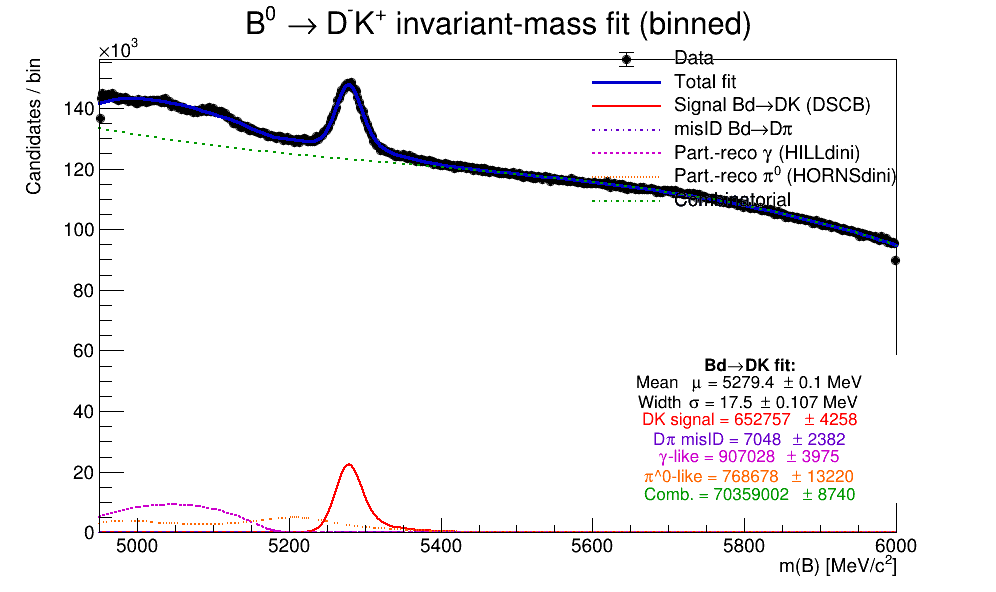

1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (sigL,sigR,BKG_comb)

(m)

NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
m)
(m)

 to calculate Int(m)
] INFO:NumericIntegration -- RooRealIntegral::init(BKG_pi_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
 to calculate Intm)(
m)

PID2475942/RooRealMPFE::nll_pdf_DK_dhDK_2c537ee0_MPFE7[ arg=nll_pdf_DK_dhDK_GOF7 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,pi_alpha,pi_n,pi_sig,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig) ]

PID2475942/RooRealMPFE::nll_pdf_DK_dhDK_2c537ee0_MPFE7[ arg=nll_pdf_DK_dhDK_GOF7 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,pi_alpha,pi_n,pi_sig,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig) ]

PID2475938/RooRealMPFE::nll_pdf_DK_dhDK_2c537ee0_MPFE3[ arg=nll_p

Warning in <TROOT::Append>: Replacing existing TH1: hDK (Potential memory leak).
Info in <TCanvas::Print>: png file /tmp/fit_DK_1762691443.png has been created



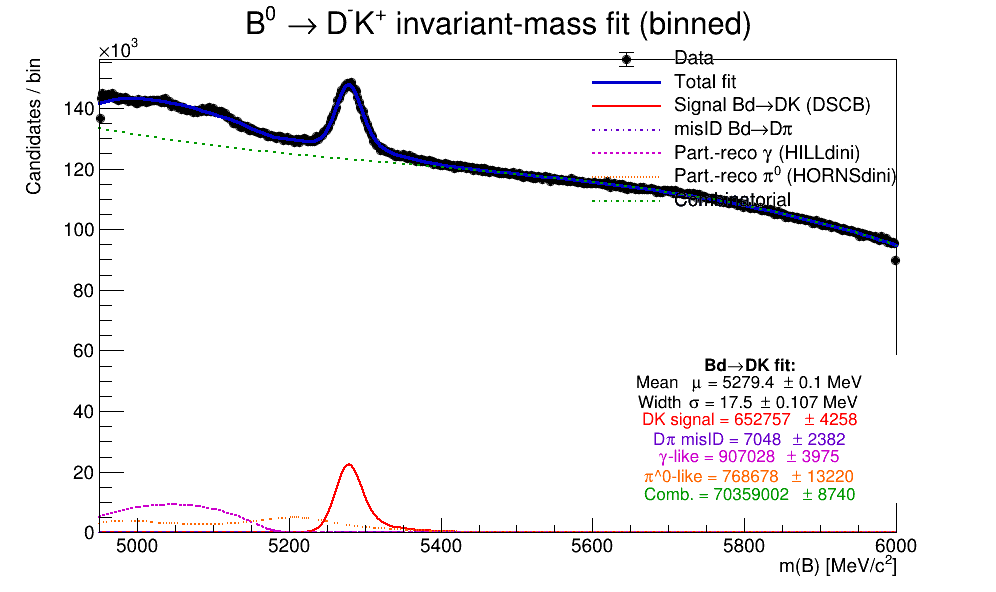

In [4]:
DK_FILES = FILES

USE_SUBSET = False
SUBSET_N   = 500_000    # optional skim, for speed

NBINS      = 600        # fine binning
COMB_MODEL = "cheby"    # "cheby" or "expo"

# physics windows
D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MIN = 8.0         # kaon-like bachelor (lab1_PIDK>8)
mmin, mmax = 4950., 6000.       # full DK window

PI_SHIFT   = 5316.0 - 5279.0    # ≈ 37 MeV shift wrt DK peak
PI_SIG0    = 32.4
PI_ALPHA0  = 1.334
PI_N0      = 0.5

# build the K-like bachelor sample
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build DK] applying Bd->DK cuts (K-like bachelor, vertex + D mass)...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in DK_FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading DK tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]
    pidk = pidk[finite]

    sel = (
        (pidk > BACHELOR_PIDK_MIN) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build DK] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No DK events after cuts/subset.")

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# sign of the combinatorial slope, seeded from a linear fit at low mass
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hDK","hDK", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhDK","binned DK", ROOT.RooArgList(m), dhist)

# seeds for the DK mean and width
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges = np.linspace(5200,5350,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model

# DK signal, a double-sided Crystal Ball
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 30.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

dMis = ROOT.RooRealVar("dMis","Dpi->DK shift", PI_SHIFT, PI_SHIFT-5., PI_SHIFT+5.)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0+@1", ROOT.RooArgList(mu,dMis))

pi_sig   = ROOT.RooRealVar("pi_sig",  "pi-like sigma",  PI_SIG0)
pi_alpha = ROOT.RooRealVar("pi_alpha","pi-like alpha",  PI_ALPHA0)
pi_n     = ROOT.RooRealVar("pi_n",    "pi-like n",      PI_N0)

# hold the misID shape at the π-like values
for v_ in (pi_sig, pi_alpha, pi_n):
    v_.setConstant(True)

MIS = ROOT.RooCBShape("MIS","misID Bd->D#pi", m, mu_mis, pi_sig, pi_alpha, pi_n)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","DK signal yield",  0.20*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","Dpi misID yield",  0.05*Ntot, 0.0, 0.5*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",      0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",        0.02*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",      0.70*Ntot, 0.0, 2.0*Ntot)

# pre-fit the combinatorial in the sidebands, and constrain it there
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

# weak priors on the partial-reco yields
mu_Ng,  sig_Ng  = 0.04*Ntot, max(1.0, 0.04*Ntot)
mu_Npi, sig_Npi = 0.02*Ntot, max(1.0, 0.02*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# prefit signal and combinatorial with the DSCB tails frozen
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_DK","pre_DK",
                         ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit DK] signal+comb (DSCB, tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

# hold the DK peak position and width at their pre-fit values
mu.setConstant(True)
sig.setConstant(True)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf_DK","DK model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit DK] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit DK] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_DK_{int(time.time())}","DKFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                       "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                  "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID Bd#rightarrowD#pi",       "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)",  "l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",                 "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Bd#rightarrowDK fit:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"DK signal = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi misID = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_DK_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved DK fit plot to {tmp_png}")


### No bachelor PID cut

Dropping the PID requirement altogether gives the inclusive B0 -> D- h+ spectrum, where DK
and D pi both appear as peaks. Useful as a check that the two shapes are separable at all
before choosing where to cut.



[build incl] Bd->D(h) inclusive sample (vertex + D mass cuts, no bachelor PID)...



Reading tuples: 61it [16:28, 16.21s/it]



[build incl] done in 992.1s — kept 118516509 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit incl] DK + Dπ + comb...

[fit incl] final binned extended likelihood, NBINS = 600
[fit incl] time: 5.2s, status=3, covQual=2
N_DK  = 435563 ± 1049
N_Dpi = 1131681 ± 2932



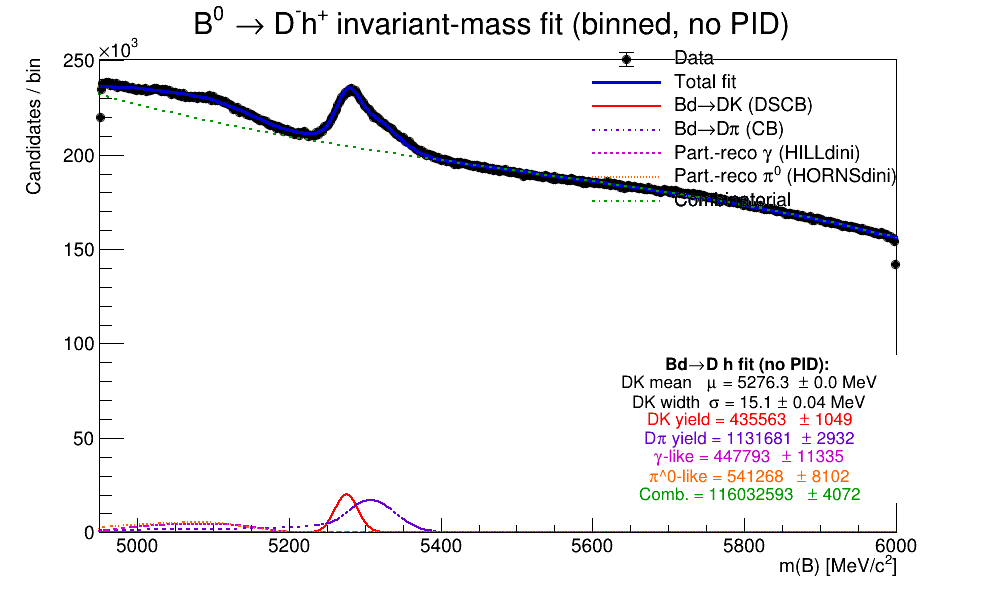


1] 1INFO] :INFO:NumericIntegrationNumericIntegration --  -- RooRealIntegral::init(RooRealIntegral::init(BKG_g_Int[m]BKG_g_Int[m]) using numeric integrator ) using numeric integrator RooRombergIntegratorRooRombergIntegrator to calculate Int to calculate Int(([#1] INFO:mm)NumericIntegration) -- 

] INFO:NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
) using numeric integrator (RooRombergIntegratorm to calculate Int)(
] INFO:NumericIntegration -- RooRealIntegral::init(BKG_pi_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)

 to calculate Int(m)

)1
] INFO:NumericIntegration -- RooRealIntegral::init(BKG_pi_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
)

PID2512884/RooRealMPFE::nll_pdf_incl_dhIncl_ae873a0_MPFE3[ arg=nll_pdf_incl_dhIncl_GOF3 vars=(N_DK,N_Dpi,Ncomb,Ng,Npi0,aL,aR,c0,c1,c2,dHb,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,pi_alpha,pi_mu,pi_n

Info in <TCanvas::Print>: png file /tmp/fit_BdDh_inclusive_1762692836.png has been created



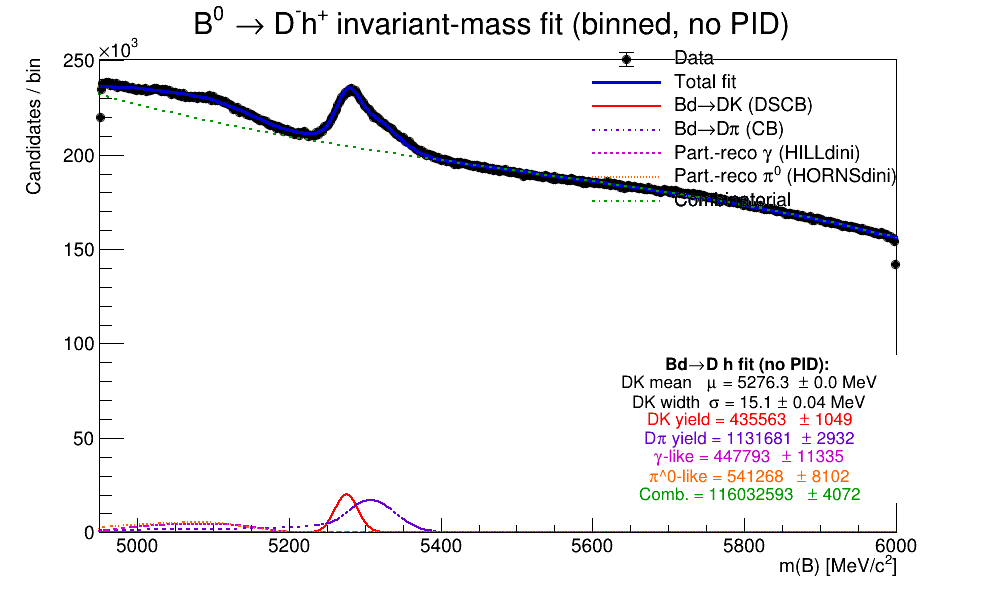

In [ ]:
USE_SUBSET = False
SUBSET_N   = 500_000    # optional skim, for speed

NBINS      = 600        # fine binning
COMB_MODEL = "cheby"    # "cheby" or "expo"

# physics windows and cuts
D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
mmin, mmax = 4950., 6000.

PI_MEAN0   = 5316.0
PI_SIG0    = 32.4
PI_ALPHA0  = 1.334
PI_N0      = 0.5

# build the inclusive sample, with no bachelor PID cut
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build incl] Bd->D(h) inclusive sample (vertex + D mass cuts, no bachelor PID)...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) &
        np.isfinite(dchi) & np.isfinite(mD)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]

    sel = (
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build incl] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No events after cuts/subset.")

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hIncl","hIncl", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhIncl","binned Bd->D(h) incl", ROOT.RooArgList(m), dhist)

# seeds for the DK mean and width
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges = np.linspace(5200,5350,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model

# DK signal, a double-sided Crystal Ball
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 30.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG_DK   = ROOT.RooAddPdf("SIG_DK","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# Dπ component, a Crystal Ball shaped by the π-like fit
pi_mu    = ROOT.RooRealVar("pi_mu",   "Dpi mean",   PI_MEAN0, PI_MEAN0-10., PI_MEAN0+10.)
pi_sig   = ROOT.RooRealVar("pi_sig",  "Dpi sigma",  PI_SIG0)
pi_alpha = ROOT.RooRealVar("pi_alpha","Dpi alpha",  PI_ALPHA0)
pi_n     = ROOT.RooRealVar("pi_n",    "Dpi n",      PI_N0)

for v_ in (pi_sig, pi_alpha, pi_n):
    v_.setConstant(True)

SIG_Dpi = ROOT.RooCBShape("SIG_Dpi","Bd->D#pi (reco as DK)", m,
                          pi_mu, pi_sig, pi_alpha, pi_n)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot   = float(np.sum(hist))
N_DK   = ROOT.RooRealVar("N_DK",  "DK yield",   0.10*Ntot, 0.0, 2.0*Ntot)
N_Dpi  = ROOT.RooRealVar("N_Dpi", "Dpi yield",  0.20*Ntot, 0.0, 2.0*Ntot)
Ng     = ROOT.RooRealVar("Ng",    "gamma yield",0.05*Ntot, 0.0, 1.0*Ntot)
Npi0   = ROOT.RooRealVar("Npi0",  "pi0 yield",  0.05*Ntot, 0.0, 1.0*Ntot)
Ncomb  = ROOT.RooRealVar("Ncomb", "comb yield", 0.60*Ntot, 0.0, 2.0*Ntot)

# pre-fit the combinatorial in the sidebands, and constrain it there
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

# weak priors on the partial-reco yields
mu_Ng,  sig_Ng  = 0.05*Ntot, max(1.0, 0.05*Ntot)
mu_Npi0, sig_Npi0 = 0.05*Ntot, max(1.0, 0.05*Ntot)
gNg   = ROOT.RooGaussian("gNg","weak prior Ng",   Ng,   RF.RooConst(mu_Ng),   RF.RooConst(sig_Ng))
gNpi0 = ROOT.RooGaussian("gNpi0","weak prior Npi0", Npi0, RF.RooConst(mu_Npi0), RF.RooConst(sig_Npi0))
constraints.addOwned(gNg); constraints.addOwned(gNpi0)

# prefit DK, Dπ and combinatorial, leaving the partial-reco out
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_incl","pre_incl",
                         ROOT.RooArgList(SIG_DK, SIG_Dpi, BKG_comb),
                         ROOT.RooArgList(N_DK, N_Dpi, Ncomb))

print("\n[prefit incl] DK + Dπ + comb...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf_incl","Bd->D(h) model",
                     ROOT.RooArgList(SIG_DK, SIG_Dpi, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(N_DK,  N_Dpi,  Ng,     Npi0,   Ncomb))

print("\n[fit incl] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit incl] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")
print(f"N_DK  = {N_DK.getValV():.0f} ± {N_DK.getError():.0f}")
print(f"N_Dpi = {N_Dpi.getValV():.0f} ± {N_Dpi.getError():.0f}")


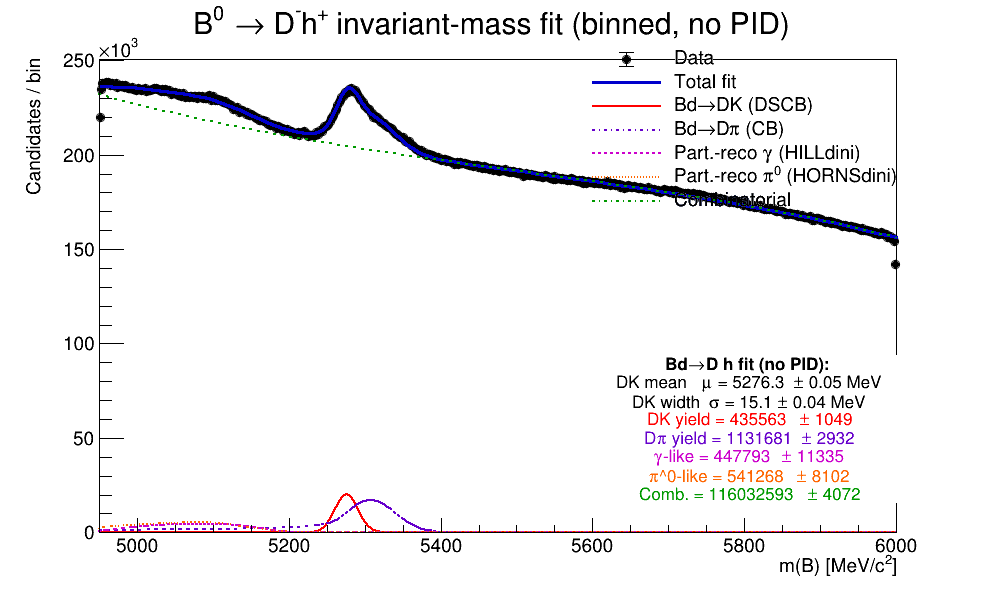



[22 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/fit_BdDh_inclusive_1762692882.png has been created



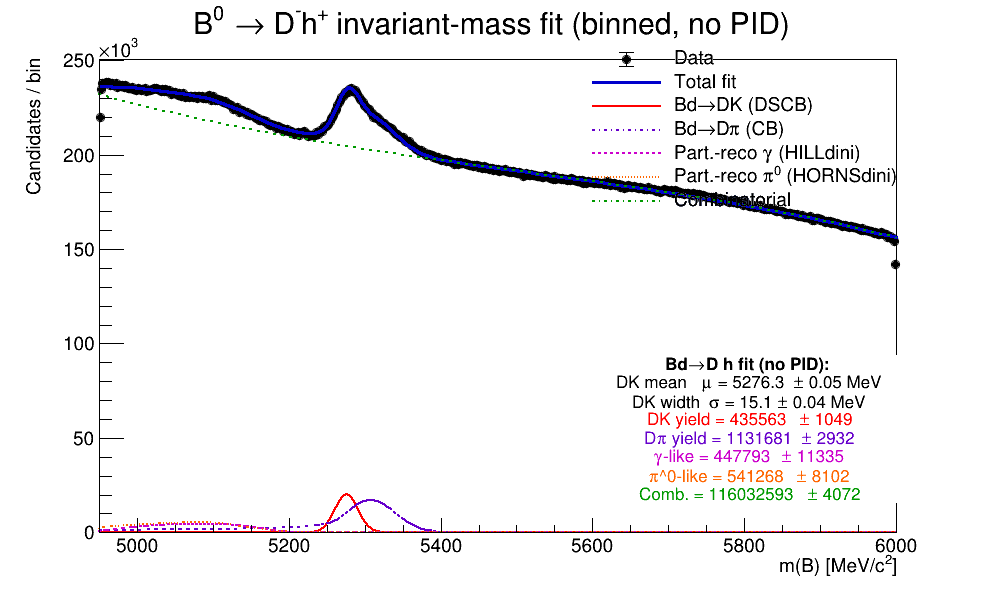

In [6]:
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}h^{+} invariant-mass fit (binned, no PID)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG_DK"),   RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("DK_line"))
pdf.plotOn(frame, RF.Components("SIG_Dpi"),  RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("Dpi_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_incl_{int(time.time())}","BdDhFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                      "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                 "l")
leg.AddEntry(frame.findObject("DK_line"),  "Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("Dpi_line"), "Bd#rightarrowD#pi (CB)", "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",        "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Bd#rightarrowD h fit (no PID):}")
box.AddText(f"DK mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.2f} MeV")
box.AddText(f"DK width #sigma = {sig.getValV():.1f} #pm {sig.getError():.2f} MeV")
t = box.AddText(f"DK yield = {N_DK.getValV():.0f} #pm {N_DK.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi yield = {N_Dpi.getValV():.0f} #pm {N_Dpi.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi0.getValV():.0f} #pm {Npi0.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_BdDh_inclusive_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved inclusive Bd->Dh fit plot to {tmp_png}")


### Loose PIDK window

Between the two extremes above: a loose window on the bachelor rather than a hard cut, to
see how much misID contamination the fit tolerates before the yields destabilise.



[build Bd->Dh] inclusive sample with -5.0 < PIDK < 10.0 ...



Reading tuples: 0it [00:00, ?it/s]


Reading tuples: 72it [00:14,  5.07it/s]



[build Bd->Dh] done in 15.5s — kept 52207452 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit loose PID] DK + Dπ + comb ...

[fit loose PID] final binned extended likelihood, NBINS = 600
[fit loose PID] time: 9.0s, status=3, covQual=2
N_DK  = 219312 ± 1308
N_Dpi = 732445 ± 2248



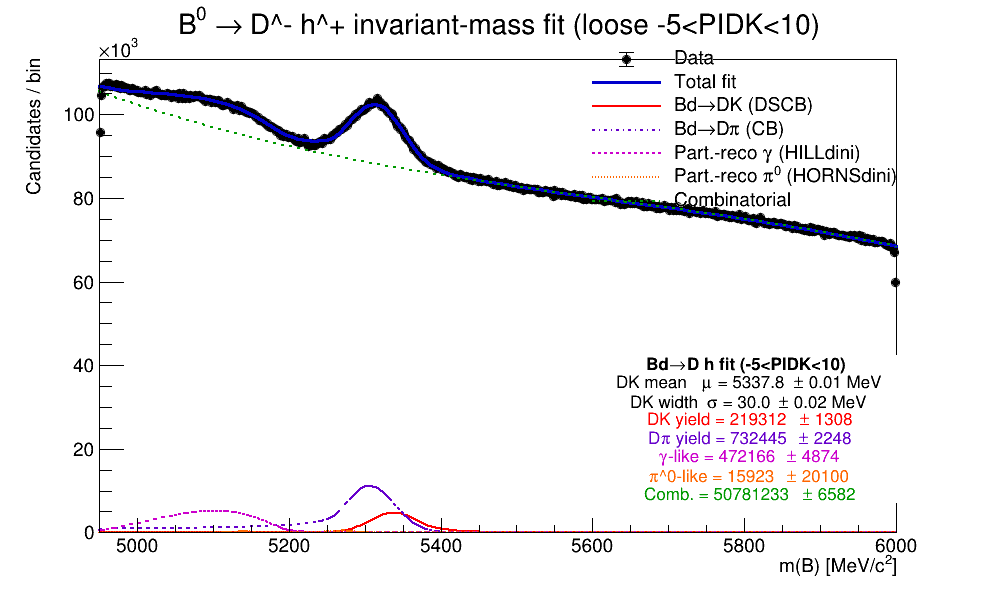


1] INFO:NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
:NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
) using numeric integrator RooRombergIntegrator to calculate Int(m)
] INFO:NumericIntegration -- RooRealIntegral::init([#BKG_pi_Int[m]) using numeric integrator 1RooRombergIntegrator]  to calculate IntINFO(:mNumericIntegration) -- 
PID2532818/RooRealMPFE::nll_pdf_loose_dhLoosePID_24c62ac0_MPFE3[ arg=nll_pdf_loose_dhLoosePID_GOF3 vars=(N_DK,N_Dpi,Ncomb,Ng,Npi0,aL,aR,c0,c1,c2,dHb,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,pi_alpha,pi_mu,pi_n,pi_sig,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig) ]

PID2532822/RooRealMPFE::nll_pdf_loose_dhLoosePID_24c62ac0_MPFE7[ arg=nll_pdf_loose_dhLoosePID_GOF7 vars=(N_DK,N_Dpi,Ncomb,Ng,Npi0,aL,aR,c0,c1,c2,dHb,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,pi_alpha,pi_mu,pi_n,pi_sig,r_a,r_cs

Warning in <TROOT::Append>: Replacing existing TH1: hLoosePID (Potential memory leak).
Info in <TCanvas::Print>: png file /tmp/fit_BdDh_loosePID_1762693224.png has been created



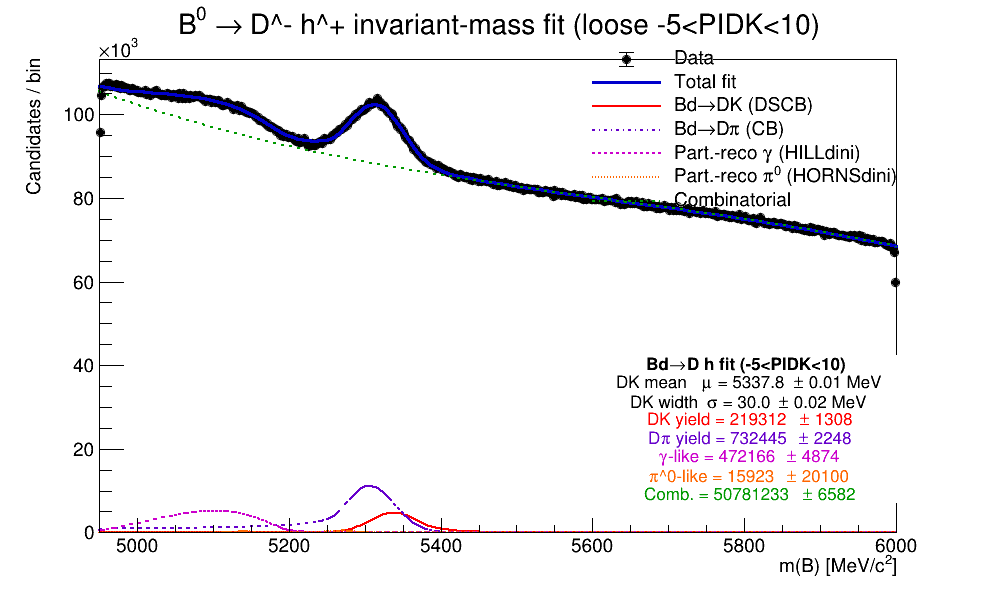

In [8]:
USE_SUBSET = False
SUBSET_N   = 500_000    # optional skim, for speed

NBINS      = 600        # fine binning
COMB_MODEL = "cheby"    # "cheby" or "expo"

# physics windows and cuts
D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
mmin, mmax = 4950., 6000.

# loose PIDK window on the bachelor
PIDK_MIN, PIDK_MAX = -5.0, 10.0

PI_MEAN0   = 5316.0
PI_SIG0    = 32.4
PI_ALPHA0  = 1.334
PI_N0      = 0.5

# build the sample inside the loose PIDK window
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build Bd->Dh] inclusive sample with {PIDK_MIN:.1f} < PIDK < {PIDK_MAX:.1f} ...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) &
        np.isfinite(dchi) & np.isfinite(mD) &
       np.isfinite(pidk)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]
    pidk = pidk[finite]

    sel = (
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW) &
        (pidk > PIDK_MIN) & (pidk < PIDK_MAX)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build Bd->Dh] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No events after cuts/subset.")

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hLoosePID","hLoosePID", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhLoosePID","binned Bd->Dh (loose PID)", ROOT.RooArgList(m), dhist)

# seeds for the DK mean and width
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges = np.linspace(5200,5350,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model

# DK signal, a double-sided Crystal Ball
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 30.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG_DK   = ROOT.RooAddPdf("SIG_DK","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# Dπ component, a Crystal Ball shaped by the π-like fit
pi_mu    = ROOT.RooRealVar("pi_mu",   "Dpi mean",   PI_MEAN0, PI_MEAN0-10., PI_MEAN0+10.)
pi_sig   = ROOT.RooRealVar("pi_sig",  "Dpi sigma",  PI_SIG0)
pi_alpha = ROOT.RooRealVar("pi_alpha","Dpi alpha",  PI_ALPHA0)
pi_n     = ROOT.RooRealVar("pi_n",    "Dpi n",      PI_N0)

# hold the Dπ shape at the π-like values
for v_ in (pi_sig, pi_alpha, pi_n):
    v_.setConstant(True)

SIG_Dpi = ROOT.RooCBShape("SIG_Dpi","Bd->D#pi", m,
                          pi_mu, pi_sig, pi_alpha, pi_n)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot   = float(np.sum(hist))
N_DK   = ROOT.RooRealVar("N_DK",  "DK yield",   0.15*Ntot, 0.0, 2.0*Ntot)
N_Dpi  = ROOT.RooRealVar("N_Dpi", "Dpi yield",  0.20*Ntot, 0.0, 2.0*Ntot)
Ng     = ROOT.RooRealVar("Ng",    "gamma yield",0.05*Ntot, 0.0, 1.0*Ntot)
Npi0   = ROOT.RooRealVar("Npi0",  "pi0 yield",  0.05*Ntot, 0.0, 1.0*Ntot)
Ncomb  = ROOT.RooRealVar("Ncomb", "comb yield", 0.55*Ntot, 0.0, 2.0*Ntot)

# pre-fit the combinatorial in the sidebands, and constrain it there
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

# weak priors on the partial-reco yields
mu_Ng,  sig_Ng    = 0.05*Ntot, max(1.0, 0.05*Ntot)
mu_Npi0, sig_Npi0 = 0.05*Ntot, max(1.0, 0.05*Ntot)
gNg   = ROOT.RooGaussian("gNg","weak prior Ng",   Ng,   RF.RooConst(mu_Ng),   RF.RooConst(sig_Ng))
gNpi0 = ROOT.RooGaussian("gNpi0","weak prior Npi0", Npi0, RF.RooConst(mu_Npi0), RF.RooConst(sig_Npi0))
constraints.addOwned(gNg); constraints.addOwned(gNpi0)

# prefit DK, Dπ and combinatorial, leaving the partial-reco out
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_loose","pre_loose",
                         ROOT.RooArgList(SIG_DK, SIG_Dpi, BKG_comb),
                         ROOT.RooArgList(N_DK, N_Dpi, Ncomb))

print("\n[prefit loose PID] DK + Dπ + comb ...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf_loose","Bd->D h model (loose PID)",
                     ROOT.RooArgList(SIG_DK, SIG_Dpi, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(N_DK,  N_Dpi,  Ng,     Npi0,   Ncomb))

print("\n[fit loose PID] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit loose PID] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")
print(f"N_DK  = {N_DK.getValV():.0f} ± {N_DK.getError():.0f}")
print(f"N_Dpi = {N_Dpi.getValV():.0f} ± {N_Dpi.getError():.0f}")

frame = m.frame(RF.Title(f"B^{{0}} #rightarrow D^- h^+ invariant-mass fit (loose {PIDK_MIN:.0f}<PIDK<{PIDK_MAX:.0f})"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG_DK"),   RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("DK_line"))
pdf.plotOn(frame, RF.Components("SIG_Dpi"),  RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("Dpi_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_loosePID_{int(time.time())}","BdDhLoosePIDFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                      "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                 "l")
leg.AddEntry(frame.findObject("DK_line"),  "Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("Dpi_line"), "Bd#rightarrowD#pi (CB)", "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",        "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText(f"#bf{{Bd#rightarrowD h fit ({PIDK_MIN:.0f}<PIDK<{PIDK_MAX:.0f})}}")
box.AddText(f"DK mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.2f} MeV")
box.AddText(f"DK width #sigma = {sig.getValV():.1f} #pm {sig.getError():.2f} MeV")
t = box.AddText(f"DK yield = {N_DK.getValV():.0f} #pm {N_DK.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi yield = {N_Dpi.getValV():.0f} #pm {N_Dpi.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi0.getValV():.0f} #pm {Npi0.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_BdDh_loosePID_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved loose-PID Bd->Dh fit plot to {tmp_png}")


## MVA scan

Scanning `lab0_MVA` against signal efficiency and background rejection, with the signal and
background regions taken from mass windows rather than from a fit.



[build] reading mass + MVA arrays and applying DK-like cuts...



[build] done in 96.8s, kept 72688484 events (before B mass window)
  m(B) range: 4950.0 – 6000.0
  MVA range:  0.0000 – 1.0000
[build] after B mass window 4950.0-6000.0: 72688476 events
[mass regions] signal_proxy: 4073623 events, background_proxy: 60554971 events

[scan] scanning lab0_MVA thresholds...
lab0_MVA > 0.1132: eps_S=0.958, R_B=0.051, J=0.009
lab0_MVA > 0.1313: eps_S=0.907, R_B=0.111, J=0.018
lab0_MVA > 0.1493: eps_S=0.863, R_B=0.163, J=0.026
lab0_MVA > 0.1673: eps_S=0.824, R_B=0.209, J=0.032
lab0_MVA > 0.1854: eps_S=0.789, R_B=0.249, J=0.038
lab0_MVA > 0.2034: eps_S=0.757, R_B=0.285, J=0.042
lab0_MVA > 0.2214: eps_S=0.728, R_B=0.318, J=0.046
lab0_MVA > 0.2395: eps_S=0.701, R_B=0.349, J=0.050
lab0_MVA > 0.2575: eps_S=0.676, R_B=0.376, J=0.053
lab0_MVA > 0.2755: eps_S=0.654, R_B=0.402, J=0.056
lab0_MVA > 0.2936: eps_S=0.632, R_B=0.426, J=0.058
lab0_MVA > 0.3116: eps_S=0.612, R_B=0.449, J=0.061
lab0_MVA > 0.3296: eps_S=0.593, R_B=0.470, J=0.063
lab0_MVA > 0.3477: eps_S=0.575, 

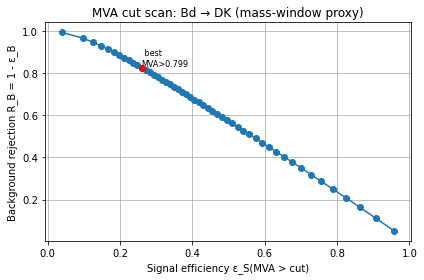

In [10]:
"""
Find best XG-like cut for Bd -> D- K+ using 2024 data.

- Uses lab0_MASS as B mass.
- Uses lab0_MVA as the classifier score ("XG").
- Applies Bd->DK-like cuts (vertex, D mass, K-like bachelor PIDK>8).
- Defines signal/background by B mass windows.
- Scans XG > cut, computes signal efficiency & background rejection.
- Chooses best cut by maximizing Youden's J = eps_S + R_B - 1.
"""

for f in FILES:
    assert os.path.exists(f), f"File not found: {f}"

USE_SUBSET   = False      # set True for a quick test
SUBSET_N     = 500_000    # max events if subset

# B mass range to consider
mmin, mmax   = 4950., 6000.

# B0 peak, and the signal and sideband regions
B0_MASS      = 5279.65    # MeV
SIG_WIN      = 25.0       # |m - B0_MASS| < SIG_WIN => signal proxy
BKG_L_MAX    = 5200.0     # left sideband:  [mmin, BKG_L_MAX]
BKG_R_MIN    = 5360.0     # right sideband: [BKG_R_MIN, mmax]

# D mass window
D_MASS       = 1869.65    # MeV
D_WINDOW     = 30.0       # |M(D) - D_MASS| < D_WINDOW

# Basic cuts (DK-like)
B_VCHI2_MAX     = 7.0
D_VCHI2_MAX     = 7.0
BACH_PIDK_MIN   = 8.0     # kaon-like bachelor

# branch names
BR_MASS        = "lab0_MASS"         # B mass
BR_XG          = "lab0_MVA"          # classifier output (no BDTGResponse_XGB_1 branch!)
BR_B_VCHI2     = "lab0_END_VCHI2DOF"
BR_D_VCHI2     = "lab2_END_VCHI2DOF"
BR_BACH_PIDK   = "lab1_PIDK"
BR_D_MASS      = "lab2_MASS"

branches = [
    BR_MASS,
    BR_XG,
    BR_B_VCHI2,
    BR_D_VCHI2,
    BR_BACH_PIDK,
    BR_D_MASS,
]

vals_all = []
xg_all   = []

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()

print("\n[build] reading mass + MVA arrays and applying DK-like cuts...")
for arrays in uproot.iterate(
    [f"{fp}:{TREE_PATH}" for fp in FILES],
    expressions=branches,
    step_size="60 MB",
    library="np",
    allow_missing=False,
):
    mB   = arrays[BR_MASS]
    XG   = arrays[BR_XG]
    bchi = arrays[BR_B_VCHI2]
    dchi = arrays[BR_D_VCHI2]
    pidk = arrays[BR_BACH_PIDK]
    mD   = arrays[BR_D_MASS]

    finite = (
        np.isfinite(mB) &
        np.isfinite(XG) &
        np.isfinite(bchi) &
        np.isfinite(dchi) &
        np.isfinite(pidk) &
        np.isfinite(mD)
    )

    sel = (
        finite &
        (bchi < B_VCHI2_MAX) &
        (dchi < D_VCHI2_MAX) &
        (pidk > BACH_PIDK_MIN) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    mB = mB[sel]
    XG = XG[sel]

    if USE_SUBSET and got < need:
        nleft = int(max(0, need - got))
        mB = mB[:nleft]
        XG = XG[:nleft]

    vals_all.append(mB)
    xg_all.append(XG)
    got += mB.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
xg   = np.concatenate(xg_all)   if xg_all   else np.array([], dtype=float)

print(f"[build] done in {time.time()-t0:.1f}s, kept {vals.size} events (before B mass window)")
if vals.size == 0:
    raise RuntimeError("0 events – check cuts or branch names.")

print(f"  m(B) range: {vals.min():.1f} – {vals.max():.1f}")
print(f"  MVA range:  {xg.min():.4f} – {xg.max():.4f}")

# restrict to the global B mass window
mask_m = (vals > mmin) & (vals < mmax)
vals = vals[mask_m]
xg   = xg[mask_m]
print(f"[build] after B mass window {mmin}-{mmax}: {vals.size} events")

# signal and background regions
sig_mask = np.abs(vals - B0_MASS) < SIG_WIN
bkg_mask = ((vals >= mmin) & (vals <= BKG_L_MAX)) | ((vals >= BKG_R_MIN) & (vals <= mmax))

xg_sig = xg[sig_mask]
xg_bkg = xg[bkg_mask]

print(f"[mass regions] signal_proxy: {xg_sig.size} events, "
      f"background_proxy: {xg_bkg.size} events")

if xg_sig.size == 0 or xg_bkg.size == 0:
    raise RuntimeError("Signal or background proxy is empty; tweak SIG_WIN / sidebands.")

# scan thresholds for ε_S, R_B and Youden's J
print("\n[scan] scanning lab0_MVA thresholds...")

xg_min = np.percentile(xg, 5)
xg_max = np.percentile(xg, 99)
thresholds = np.linspace(xg_min, xg_max, 50)

eff_s  = []
rej_b  = []
youden = []

for thr in thresholds:
    s_pass = np.sum(xg_sig > thr)
    b_pass = np.sum(xg_bkg > thr)
    s_tot  = xg_sig.size
    b_tot  = xg_bkg.size

    eps_s = s_pass / s_tot if s_tot > 0 else 0.0   # signal efficiency
    eps_b = b_pass / b_tot if b_tot > 0 else 0.0   # background efficiency
    R_b   = 1.0 - eps_b                            # background rejection
    J     = eps_s + R_b - 1.0                      # Youden's J

    eff_s.append(eps_s)
    rej_b.append(R_b)
    youden.append(J)

    print(f"lab0_MVA > {thr:.4f}: eps_S={eps_s:.3f}, R_B={R_b:.3f}, J={J:.3f}")

eff_s  = np.array(eff_s)
rej_b  = np.array(rej_b)
youden = np.array(youden)

best_idx   = np.argmax(youden)
best_thr   = thresholds[best_idx]
best_eps_s = eff_s[best_idx]
best_R_b   = rej_b[best_idx]
best_J     = youden[best_idx]

print("\n[best cut]")
print(f"  lab0_MVA > {best_thr:.4f}")
print(f"  signal efficiency   ε_S = {best_eps_s:.3f}")
print(f"  background rejection R_B = {best_R_b:.3f}")
print(f"  Youden's J          J   = {best_J:.3f}")

# ROC-like curve, ε_S against R_B
plt.figure()
plt.plot(eff_s, rej_b, marker="o")
plt.scatter([best_eps_s], [best_R_b], color="red", zorder=5)
plt.text(best_eps_s, best_R_b,
         f" best\nMVA>{best_thr:.3f}",
         fontsize=8, ha="left", va="bottom")

plt.xlabel("Signal efficiency ε_S(MVA > cut)")
plt.ylabel("Background rejection R_B = 1 - ε_B")
plt.title("MVA cut scan: Bd → DK (mass-window proxy)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Tighter selection, MVA > 0.799

The final version in this notebook: the MVA cut from the scan above, tighter PID and vertex
requirements, and a right-tailed Crystal Ball for the misID component. Mass window kept at
4950-6000 MeV so the yields stay comparable with the earlier fits.



[build DK] applying Bd->DK cuts (PIDK>10.0, vertex + D mass, FDCHI2>100.0, IPCHI2<15.0, DIRA>0.9995, lab0_MVA>0.799)...



Reading DK tuples: 111it [15:19,  8.28s/it]



[build DK] done in 919.2s — kept 4862056 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit DK] signal+comb (DSCB, tails frozen)...

[fit DK] final binned extended likelihood, NBINS = 600
[fit DK] time: 9.7s, status=3, covQual=2



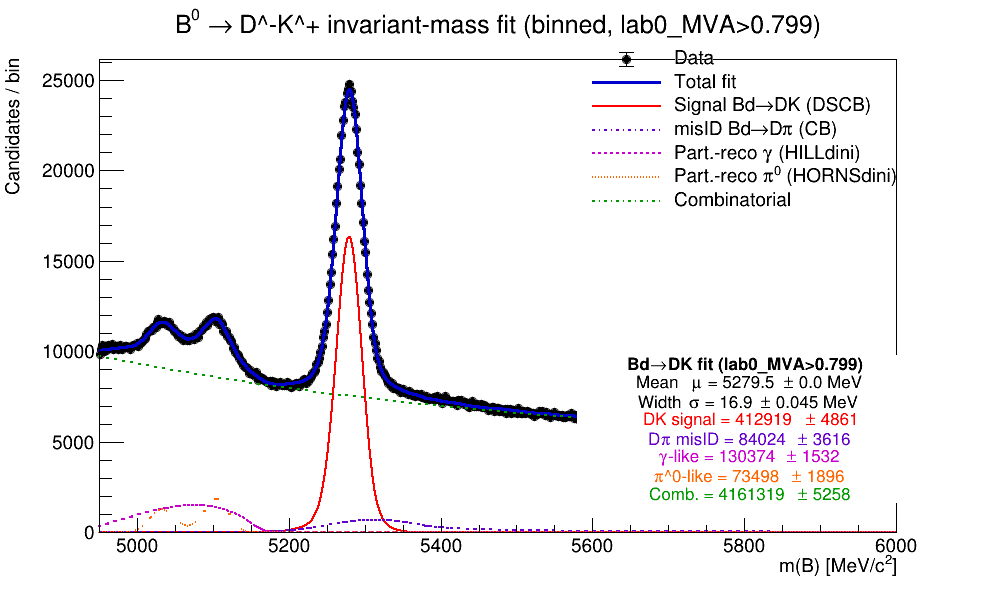

] ,INFOBKG_comb:)
Minimization --  The following expressions will be evaluated in cache-and-track mode: (sigL,sigR,BKG_comb)
)
m)
(m)
) using numeric integrator RooRombergIntegrator to calculate Int(m)
:BKG_g_Int[m]) using numeric integrator NumericIntegrationRooRombergIntegrator --  to calculate IntRooRealIntegral::init(BKG_g_Int[m]() using numeric integrator mRooRombergIntegrator) to calculate Int
(m)
NumericIntegration) using numeric integrator  -- RooRombergIntegratorRooRealIntegral::init( to calculate IntBKG_pi_Int[m]() using numeric integrator mRooRombergIntegrator) to calculate Int
(m)
PID3215649/RooRealMPFE::nll_pdf_DK_dhDK_2a0f0430_MPFE0[ arg=nll_pdf_DK_dhDK_GOF0 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,alpha_mis,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,n_mis,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig,sig_mis) ]

PID3215651/RooRealMPFE::nll_pdf_DK_dhDK_2a0f0430_MPFE2[ arg=nll_pdf_DK_dhDK_GOF2 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,alpha_mis,c0,c1,c2,dHb,dMis,d

Warning in <TROOT::Append>: Replacing existing TH1: hDK (Potential memory leak).
Info in <TCanvas::Print>: png file /tmp/fit_DK_MVAcut_1762713385.png has been created



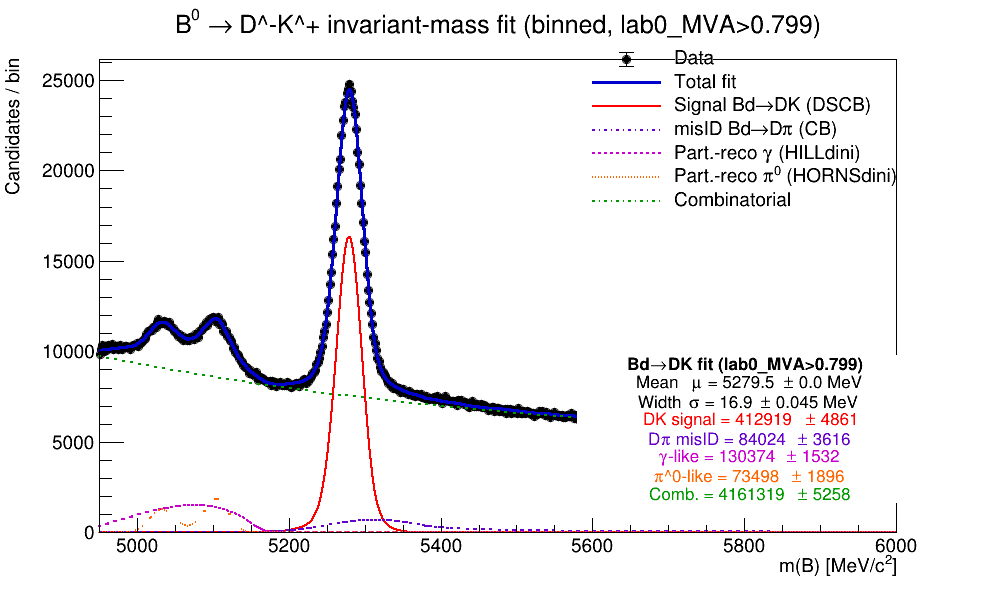

In [14]:
DK_FILES = FILES

USE_SUBSET = False
SUBSET_N   = 500_000    # optional skim, for speed

NBINS      = 600        # fine binning
COMB_MODEL = "cheby"    # "cheby" or "expo"

# physics windows
D_MASS, D_WINDOW = 1869.65, 20.0   # tighter D window
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 5.0, 5.0
BACHELOR_PIDK_MIN = 10.0           # tighter kaon PID
B_FDCHI2_MIN      = 100.0          # B flight distance chi2
B_IPCHI2_MAX      = 15.0           # B IP chi2
B_DIRA_MIN        = 0.9995         # B pointing

mmin, mmax = 4950., 6000.

# MVA cut from the scan
MVA_BRANCH = "lab0_MVA"
MVA_CUT    = 0.799

# build the K-like bachelor sample under the tighter cuts
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
    "lab0_BPVFDCHI2", "lab0_BPVIPCHI2", "lab0_BPVDIRA",
    MVA_BRANCH,
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build DK] applying Bd->DK cuts (PIDK>{BACHELOR_PIDK_MIN}, vertex + D mass, "
      f"FDCHI2>{B_FDCHI2_MIN}, IPCHI2<{B_IPCHI2_MAX}, DIRA>{B_DIRA_MIN}, {MVA_BRANCH}>{MVA_CUT})...")

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in DK_FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading DK tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]
    fdchi2 = arrays["lab0_BPVFDCHI2"]
    ipchi2 = arrays["lab0_BPVIPCHI2"]
    dira   = arrays["lab0_BPVDIRA"]
    mva  = arrays[MVA_BRANCH]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk) &
        np.isfinite(fdchi2) & np.isfinite(ipchi2) & np.isfinite(dira) &
        np.isfinite(mva)
    )

    mB    = mB[finite]
    bchi  = bchi[finite]
    dchi  = dchi[finite]
    mD    = mD[finite]
    pidk  = pidk[finite]
    fdchi2= fdchi2[finite]
    ipchi2= ipchi2[finite]
    dira  = dira[finite]
    mva   = mva[finite]

    sel = (
        (pidk > BACHELOR_PIDK_MIN) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW) &
        (fdchi2 > B_FDCHI2_MIN) &
        (ipchi2 < B_IPCHI2_MAX) &
        (dira   > B_DIRA_MIN) &
        (mva    > MVA_CUT)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build DK] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError("No DK events after cuts/subset.")

# binned dataset
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# sign of the combinatorial slope, seeded from a linear fit at low mass
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("hDK","hDK", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dhDK","binned DK", ROOT.RooArgList(m), dhist)

# seeds for the DK mean and width
focus = vals[(vals>5200)&(vals<5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200,5350))
    edges = np.linspace(5200,5350,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# physics model

# DK signal, a double-sided Crystal Ball
mu  = ROOT.RooRealVar("mu","DK mean", mu0, mu0-20., mu0+20.)
sig = ROOT.RooRealVar("sig","DK sigma", sig0, 8., 25.)

aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB DK",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB DK", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB_DK", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

dMis   = ROOT.RooRealVar("dMis","D#pi->DK shift",50.0,30.0,80.0)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0+@1", ROOT.RooArgList(mu,dMis))

sig_mis   = ROOT.RooRealVar("sig_mis","misID width",1.4*sig0, sig0, 3.0*sig0)
alpha_mis = ROOT.RooRealVar("alpha_mis","alpha_mis",-1.5,-8.0,-0.2)  # negative -> tail to right
n_mis     = ROOT.RooRealVar("n_mis","n_mis",3.0,1.0,20.0)

MIS = ROOT.RooCBShape("MIS","misID Bd->D#pi", m, mu_mis, sig_mis, alpha_mis, n_mis)

# partially reconstructed γ (HILLdini) and π0 (HORNSdini)
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi0-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# combinatorial
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# extended yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","DK signal yield",  0.35*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","Dpi misID yield",  0.05*Ntot, 0.0, 0.5*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",      0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",        0.02*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",      0.54*Ntot, 0.0, 2.0*Ntot)

# pre-fit the combinatorial in the 4950-5150 and 5600-6000 sidebands
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5600, 6000)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

mu_Ng,  sig_Ng  = 0.04*Ntot, max(1.0, 0.04*Ntot)
mu_Npi, sig_Npi = 0.02*Ntot, max(1.0, 0.02*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# prefit signal and combinatorial with the DSCB tails frozen, then freeze the mean and width
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre_DK","pre_DK",
                         ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit DK] signal+comb (DSCB, tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

mu.setConstant(True)
sig.setConstant(True)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf_DK","DK model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit DK] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit DK] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

frame = m.frame(RF.Title(f"B^{{0}} #rightarrow D^-K^+ invariant-mass fit (binned, {MVA_BRANCH}>{MVA_CUT:.3f})"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_DK_{int(time.time())}","DKFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                       "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",                  "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal Bd#rightarrowDK (DSCB)", "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID Bd#rightarrowD#pi (CB)",  "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)",  "l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",                 "l")
leg.Draw()

box = ROOT.TPaveText(0.58, 0.15, 0.93, 0.40, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText(f"#bf{{Bd#rightarrowDK fit ({MVA_BRANCH}>{MVA_CUT:.3f})}}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"DK signal = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"D#pi misID = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_DK_MVAcut_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved DK fit plot to {tmp_png}")
